# Week 12 (Module 23) - BBO capstone driver

Round 12 - the LAST searching round before the final lock-in. W11 was the best round of the project (4 new bests including f1's first positive reading).

**New this round: PCA-aimed stepping.** For the two live pockets (f6, f7), the top-6 points are projected onto their principal axis; the score trend along that axis gives the uphill direction, and the weekly tiny step follows it instead of a random draw. On f7 the top-6 scores order PERFECTLY along the axis (1.857 > 1.839 > 1.819 > 1.720 > 1.688 > 1.365) - the pocket has a real, consistent slope.

**Plan:**
- **f1 -> (0.43, 0.455)**: continue the line through the sign flip (-0.0053 at (0.407,0.466) -> +0.0027 at (0.42,0.46) -> onward).
- **f2 -> tiny step** near the 0.682 winner (lock already known - low-risk slot).
- **f3 -> partition pick** (free slot; never beaten in 11 rounds - a no-risk long shot).
- **f4 -> clean single-axis probe** (+0.005 on x4 only; lock guaranteed regardless).
- **f5 -> space_fill** (free exploration; (1,1,1,1) banked).
- **f6, f7 -> PCA-aimed steps** along each pocket's uphill axis.
- **f8 -> MES** (five consecutive improvements).

NN-for-new-regions was considered and rejected: the W4 evidence (predicted 2.14, actual -17.9) still stands at these sample sizes. PCA-for-new-regions rejected too: components would reflect our clustered sampling, not the functions' structure. PCA earns its place only as a step-aimer on established pockets.


In [1]:
%matplotlib inline
import os, sys, warnings
warnings.filterwarnings("ignore")
_root = os.getcwd()
while not os.path.exists(os.path.join(_root, "bo.py")) and os.path.dirname(_root) != _root:
    _root = os.path.dirname(_root)
os.chdir(_root); sys.path.insert(0, _root)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import bo, partition_bo

WEEK, SEED = 12, 12
rng = np.random.default_rng(SEED)
OUTDIR = f"outputs/week{WEEK:02d}"; os.makedirs(OUTDIR, exist_ok=True)

results = {}

# f1: continue the line through the sign flip.
f1_x = np.array([0.430000, 0.455000])
m1 = bo.fit(1)
results[1] = dict(x=f1_x, u=f1_x, submission=bo.format_submission(f1_x),
                  acq="signal_step", mean=float('nan'), std=float('nan'),
                  incumbent_y=0.0027, n_data=len(m1.y), model=m1)

# f2: tiny step near the 0.682 winner.
X2, y2, _ = bo.load(2)
x2n = np.clip(X2[int(np.argmax(y2))] + rng.normal(0, 0.008, 2), 0.0, 0.999999)
m2 = bo.fit(2); mu2, sd2 = m2.predict(bo.to_unit(x2n.reshape(1,-1), m2.b))
results[2] = dict(x=x2n, u=bo.to_unit(x2n.reshape(1,-1), m2.b).reshape(-1),
                  submission=bo.format_submission(x2n), acq="tight_refine",
                  mean=float(mu2[0]), std=float(sd2[0]), incumbent_y=float(y2.max()),
                  n_data=len(y2), model=m2)

# f3: partition pick (free slot).
r3 = partition_bo.propose(3, seed=SEED)
m3 = bo.fit(3)
r3["incumbent_y"], r3["n_data"], r3["model"] = m3.y_best, len(m3.y), m3
results[3] = r3

# f4: clean single-axis probe (+0.005 on x4 only); lock guaranteed regardless.
f4_x = np.array([0.409370, 0.417326, 0.352834, 0.440452])
m4 = bo.fit(4); mu4, sd4 = m4.predict(bo.to_unit(f4_x.reshape(1,-1), m4.b))
results[4] = dict(x=f4_x, u=bo.to_unit(f4_x.reshape(1,-1), m4.b).reshape(-1),
                  submission=bo.format_submission(f4_x), acq="axis_probe",
                  mean=float(mu4[0]), std=float(sd4[0]), incumbent_y=0.540129,
                  n_data=len(m4.y), model=m4)

# f5: free exploration.
results[5] = bo.run_function(5, seed=SEED, acq="space_fill")

# f6, f7: PCA-aimed steps along each pocket's uphill axis.
def pca_step(fid, k=6, step=0.015):
    X, y, d = bo.load(fid)
    idx = np.argsort(y)[::-1][:k]
    Xt, yt = X[idx], y[idx]
    A = Xt - Xt.mean(axis=0)
    _, _, Vt = np.linalg.svd(A, full_matrices=False)
    pc1 = Vt[0]
    slope = np.polyfit(A @ pc1, yt, 1)[0]
    direction = pc1 if slope > 0 else -pc1
    x_new = np.clip(X[int(np.argmax(y))] + step * direction, 0.0, 0.999999)
    m = bo.fit(fid); mu, sd = m.predict(bo.to_unit(x_new.reshape(1,-1), m.b))
    return dict(x=x_new, u=bo.to_unit(x_new.reshape(1,-1), m.b).reshape(-1),
                submission=bo.format_submission(x_new), acq="pca_step",
                mean=float(mu[0]), std=float(sd[0]), incumbent_y=float(y.max()),
                n_data=len(y), model=m)

results[6] = pca_step(6)
results[7] = pca_step(7)

# f8: MES.
results[8] = bo.run_function(8, seed=SEED, acq="mes")

# Acquisition values at every proposed point (for the appendix table).
for fid in bo.FUNC_IDS:
    r = results[fid]
    if "acq_all" not in r:
        m = r["model"]
        r["acq_all"] = {k: float(v[0]) for k, v in bo.acq_values(m, r["u"].reshape(1, -1)).items()}
    bo.validate_submission(r["submission"], len(r["x"]))

pd.DataFrame([dict(func=f"f{fid}", source=results[fid]["acq"],
                   incumbent=round(results[fid]["incumbent_y"], 4),
                   submission=results[fid]["submission"]) for fid in bo.FUNC_IDS])


,func,source,incumbent,submission
0,f1,signal_step,0.0027,0.430000-0.455000
1,f2,tight_refine,0.6823,0.699796-0.055507
2,f3,partition_ei,-0.0348,0.393839-0.990914-0.084696
3,f4,axis_probe,0.5401,0.409370-0.417326-0.352834-0.440452
4,f5,space_fill,8662.4050,0.075268-0.993319-0.020411-0.829398
5,f6,pca_step,-0.1497,0.460228-0.382447-0.584549-0.726647-0.000083
6,f7,pca_step,1.8573,0.000000-0.113447-0.042472-0.167468-0.328162-0...
7,f8,mes,9.9499,0.121754-0.148784-0.117997-0.212840-0.999999-0...


## 1. Data - seed the working CSVs and review the function descriptions

In [2]:
bo.seed_csvs()          # data/f1..f8.csv from initial_data/*.npy (no-op once they exist)
bo.write_descriptions() # data/function_descriptions.csv
pd.read_csv("data/function_descriptions.csv")[["func", "dims", "n_seed", "character", "application"]]

,func,dims,n_seed,character,application
0,1,2,10,Sparse/flat (mostly ~0 except near sources); m...,Radiation/contamination source detection in a ...
1,2,2,10,Noisy + multimodal with many local peaks.,Mystery ML model returning a noisy log-likelih...
2,3,3,15,Maximise a negated cost (toward 0).,Drug discovery: combinations of three compound...
3,4,4,30,Dynamic with many local optima.,Warehouse product-placement surrogate; output ...
4,5,4,20,"Typically unimodal, a single peak.",Chemical-process yield.
5,6,5,20,Negative-by-design; maximise toward 0.,Cake recipe with five ingredients; combined ne...
6,7,6,30,Black-box; literature priors can inform the se...,"ML hyperparameter tuning (lr, reg, #layers...)..."
7,8,8,40,High-dimensional; global optimisation hard.,"8-param ML hyperparameter tuning (lr, batch, l..."


## 2. Fit a surrogate and propose the next query for all 8 functions

In [3]:
summary = pd.DataFrame([
    dict(func=f"f{fid}", d=len(results[fid]["x"]), n_data=results[fid]["n_data"],
         incumbent_y=round(results[fid]["incumbent_y"], 4),
         pred_mean=round(results[fid]["mean"], 4) if results[fid]["mean"]==results[fid]["mean"] else None,
         pred_std=round(results[fid]["std"], 4) if results[fid]["std"]==results[fid]["std"] else None,
         acq_used=results[fid]["acq"], submission=results[fid]["submission"])
    for fid in bo.FUNC_IDS
])
summary


,func,d,n_data,incumbent_y,pred_mean,pred_std,acq_used,submission
0,f1,2,21,0.0027,NaN,NaN,signal_step,0.430000-0.455000
1,f2,2,21,0.6823,0.6616,0.0274,tight_refine,0.699796-0.055507
2,f3,3,26,-0.0348,-0.0426,0.0076,partition_ei,0.393839-0.990914-0.084696
3,f4,4,41,0.5401,0.3973,0.1580,axis_probe,0.409370-0.417326-0.352834-0.440452
4,f5,4,31,8662.4050,-331.3198,688.1900,space_fill,0.075268-0.993319-0.020411-0.829398
5,f6,5,31,-0.1497,-0.2360,0.0649,pca_step,0.460228-0.382447-0.584549-0.726647-0.000083
6,f7,6,41,1.8573,1.8231,0.0343,pca_step,0.000000-0.113447-0.042472-0.167468-0.328162-0...
7,f8,8,51,9.9499,9.9500,0.0013,mes,0.121754-0.148784-0.117997-0.212840-0.999999-0...


### Acquisition values at each proposed point
All four acquisitions are computed every round so the choice can be justified in the reflection.

In [4]:
pd.DataFrame([
    dict(func=f"f{fid}", **{k: round(v, 4) for k, v in results[fid]["acq_all"].items()})
    for fid in bo.FUNC_IDS
])


,func,ei,ucb,pi,var
0,f1,0.0000,0.0027,0.0000,0.0000
1,f2,0.0018,0.7163,0.1304,0.0007
2,f3,0.0032,0.0034,0.2492,0.0005
3,f4,0.0140,0.7133,0.1667,0.0250
4,f5,0.0000,1045.0602,0.0000,473605.4941
5,f6,0.0020,-0.1063,0.0688,0.0042
6,f7,0.0016,1.8917,0.0986,0.0012
7,f8,0.0000,9.9526,0.0000,0.0000


## 3. Visualise
2D functions get full posterior + acquisition heatmaps; higher-D functions get 1D slices
through the incumbent. Every function gets convergence + leave-one-out diagnostics.

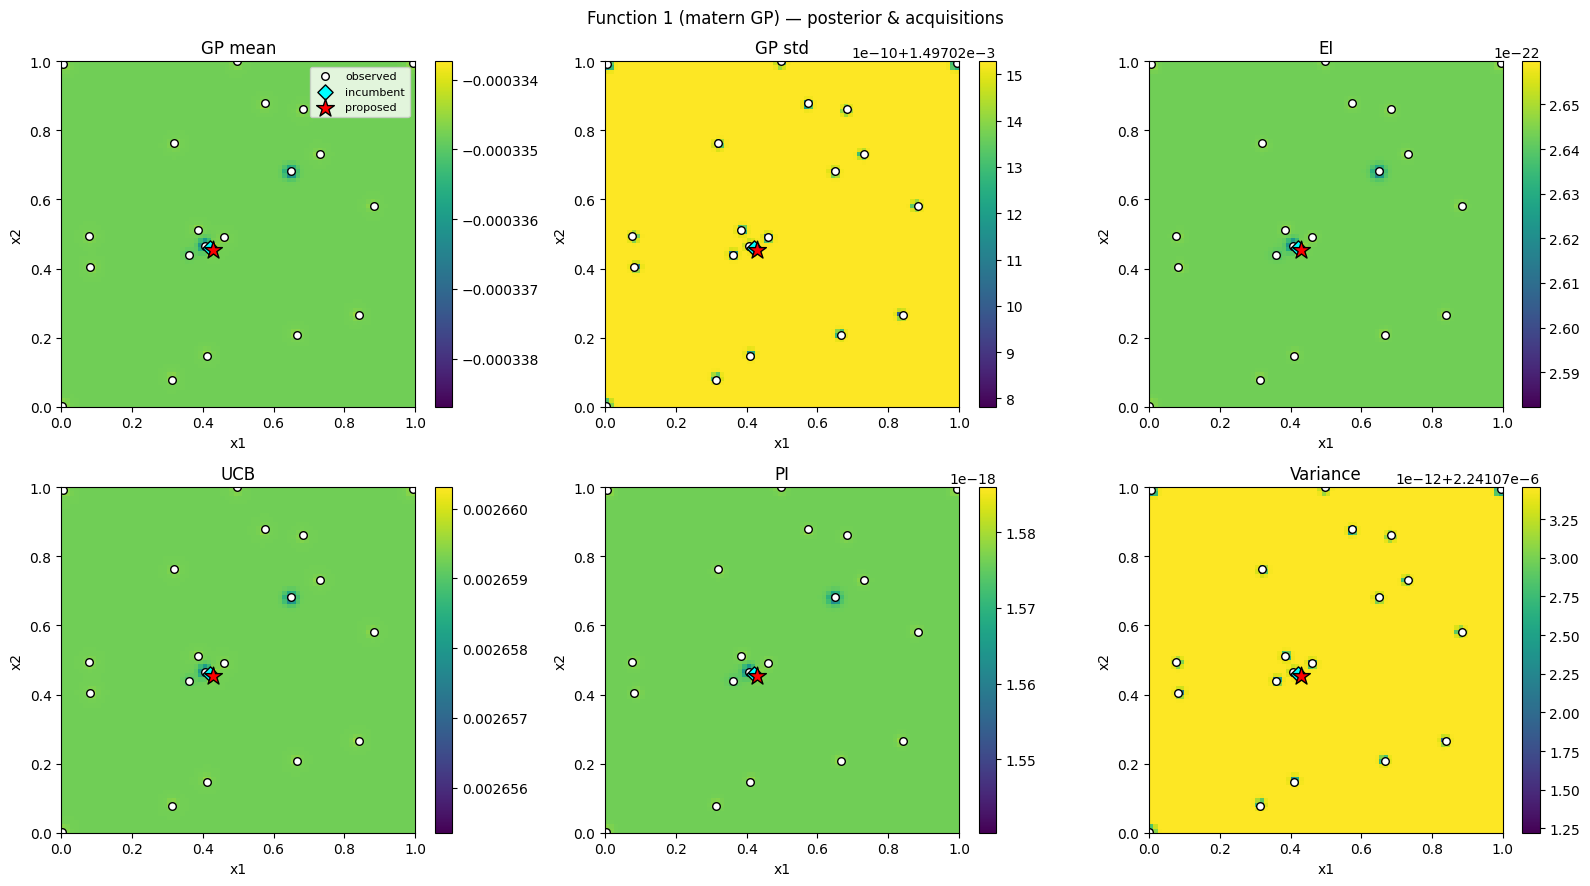

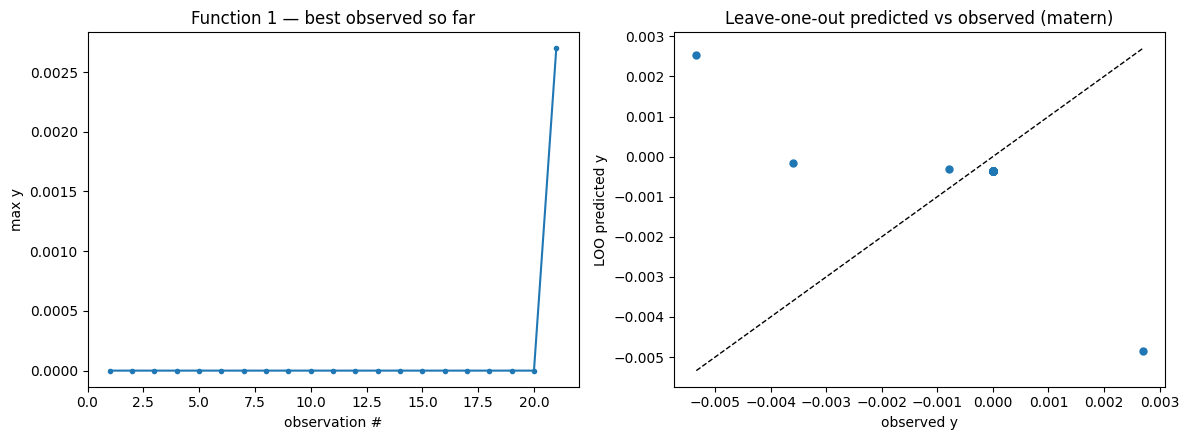

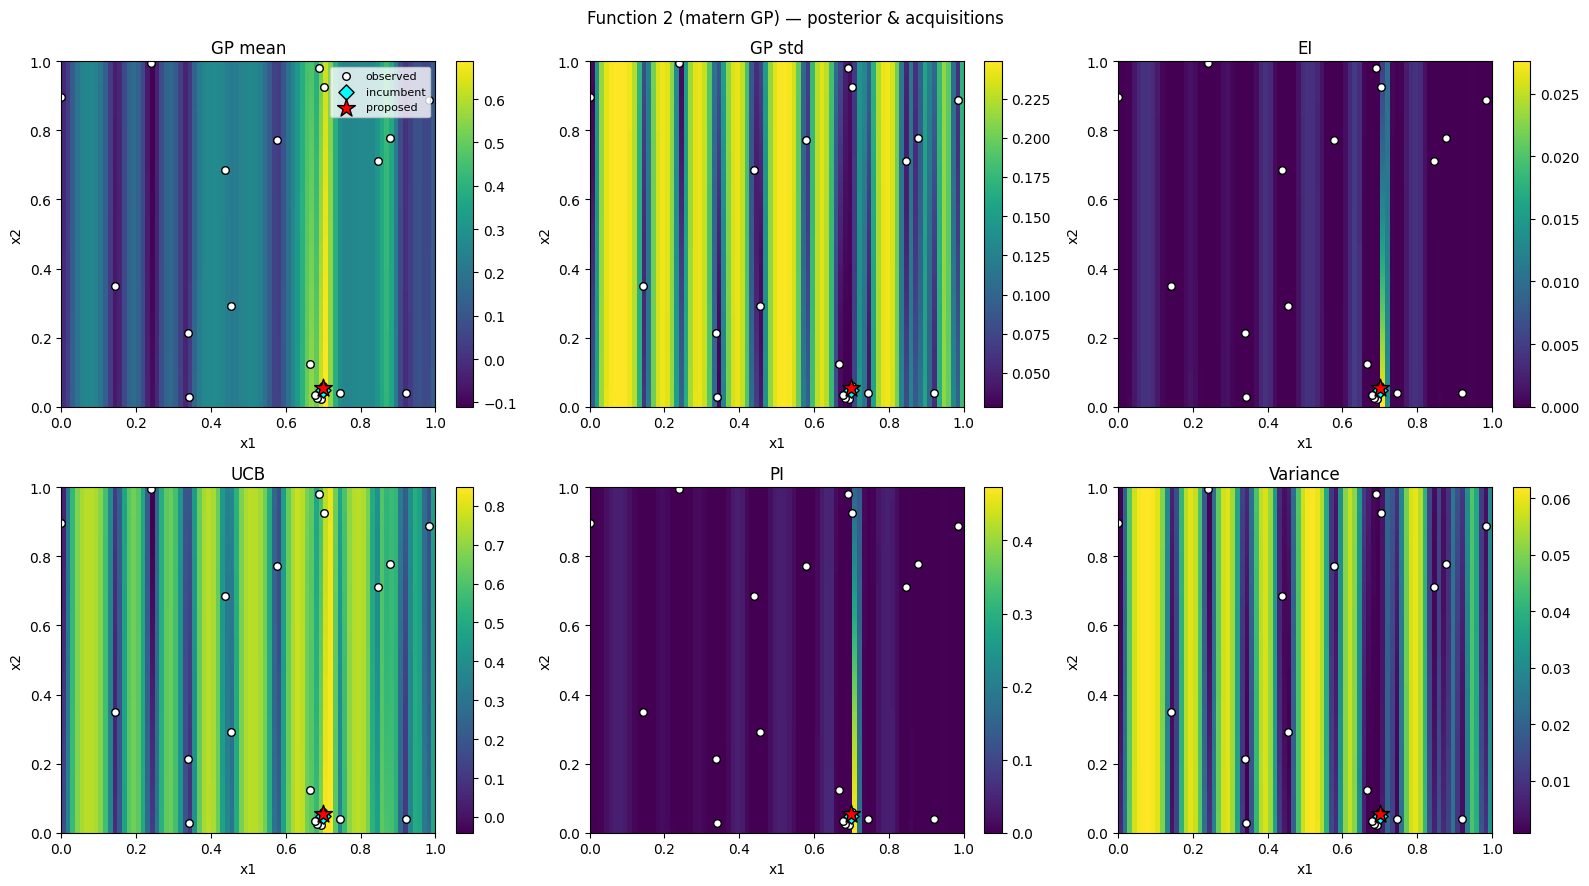

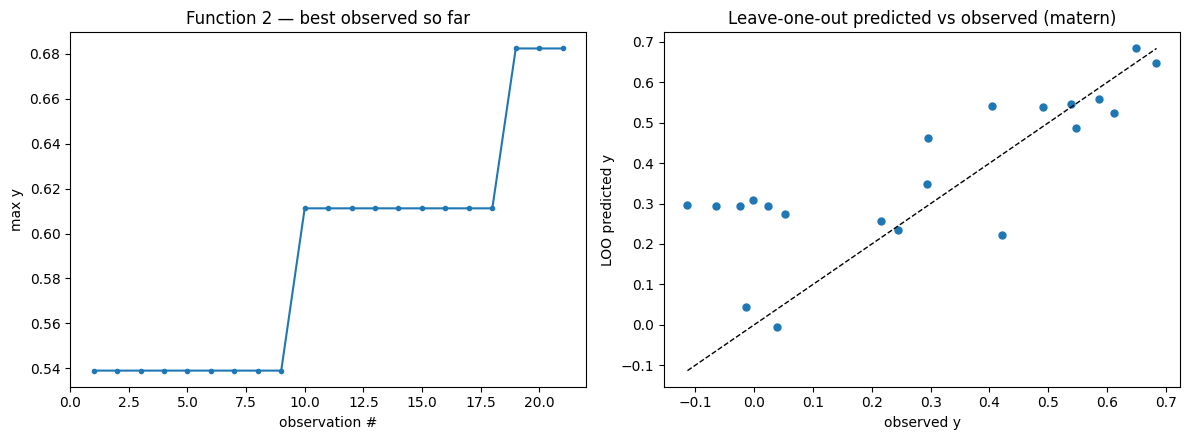

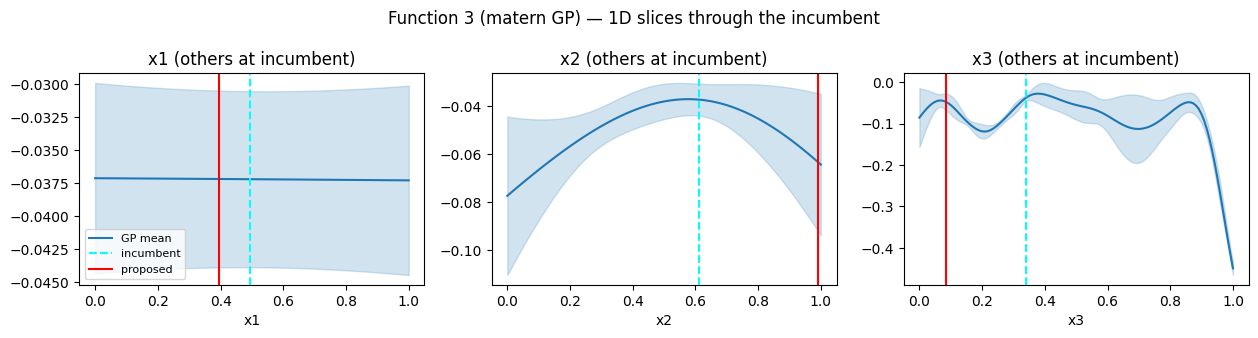

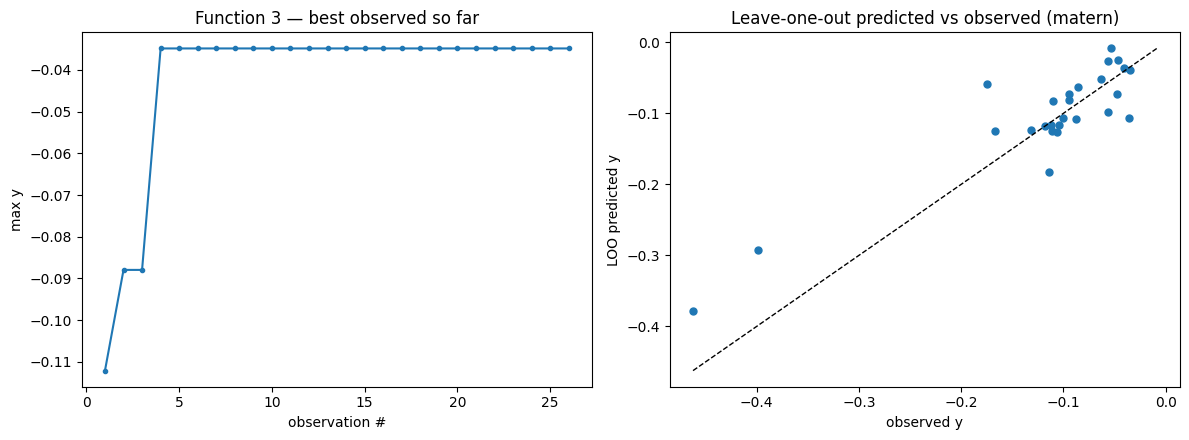

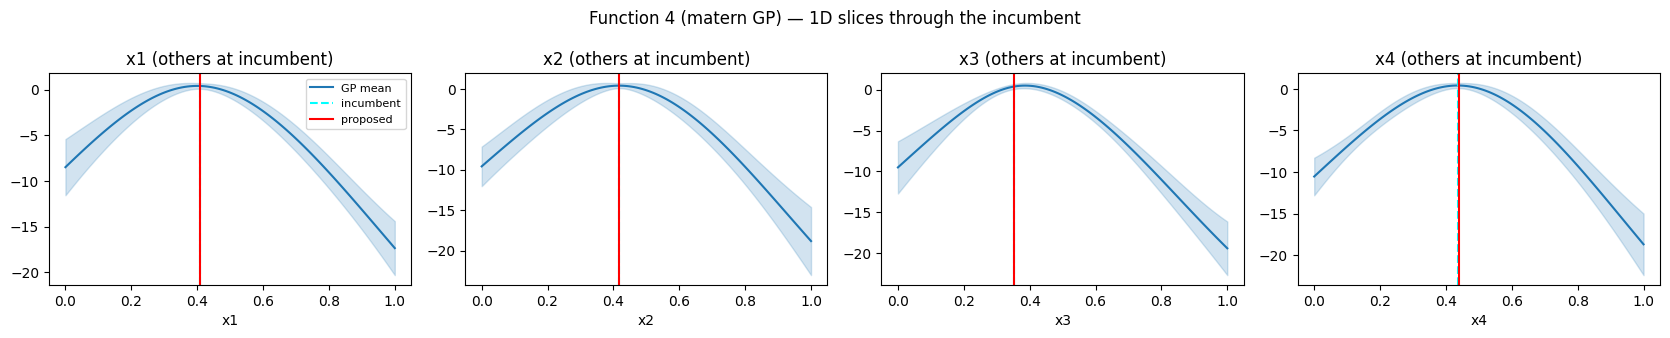

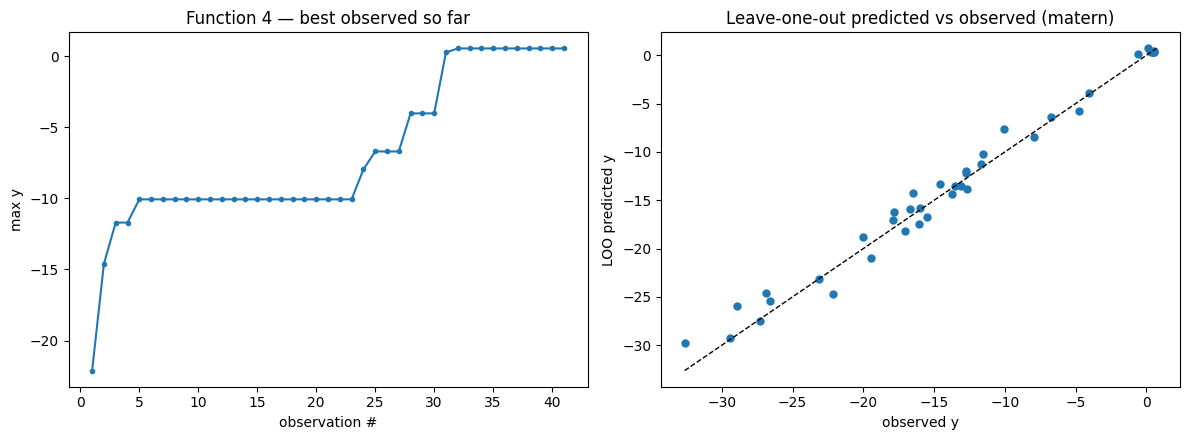

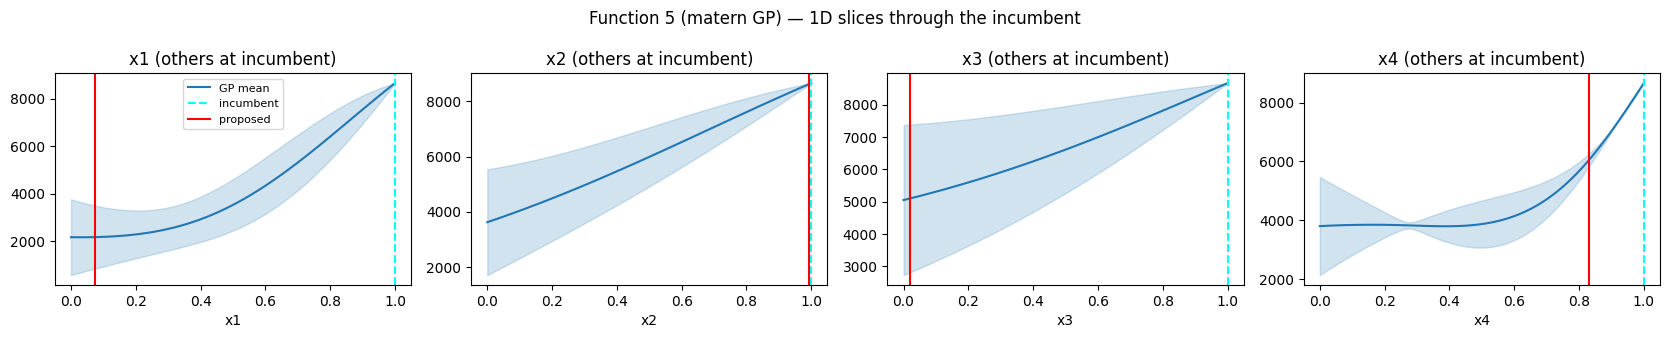

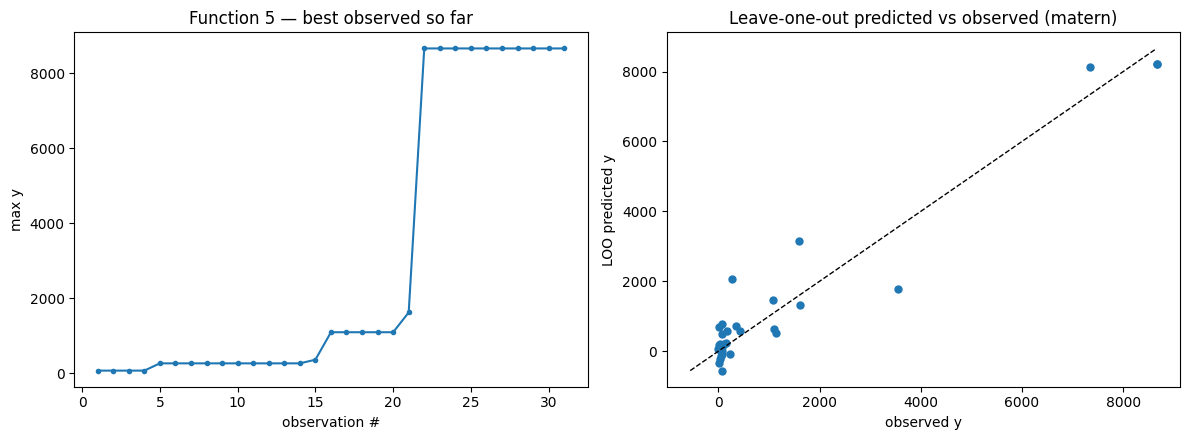

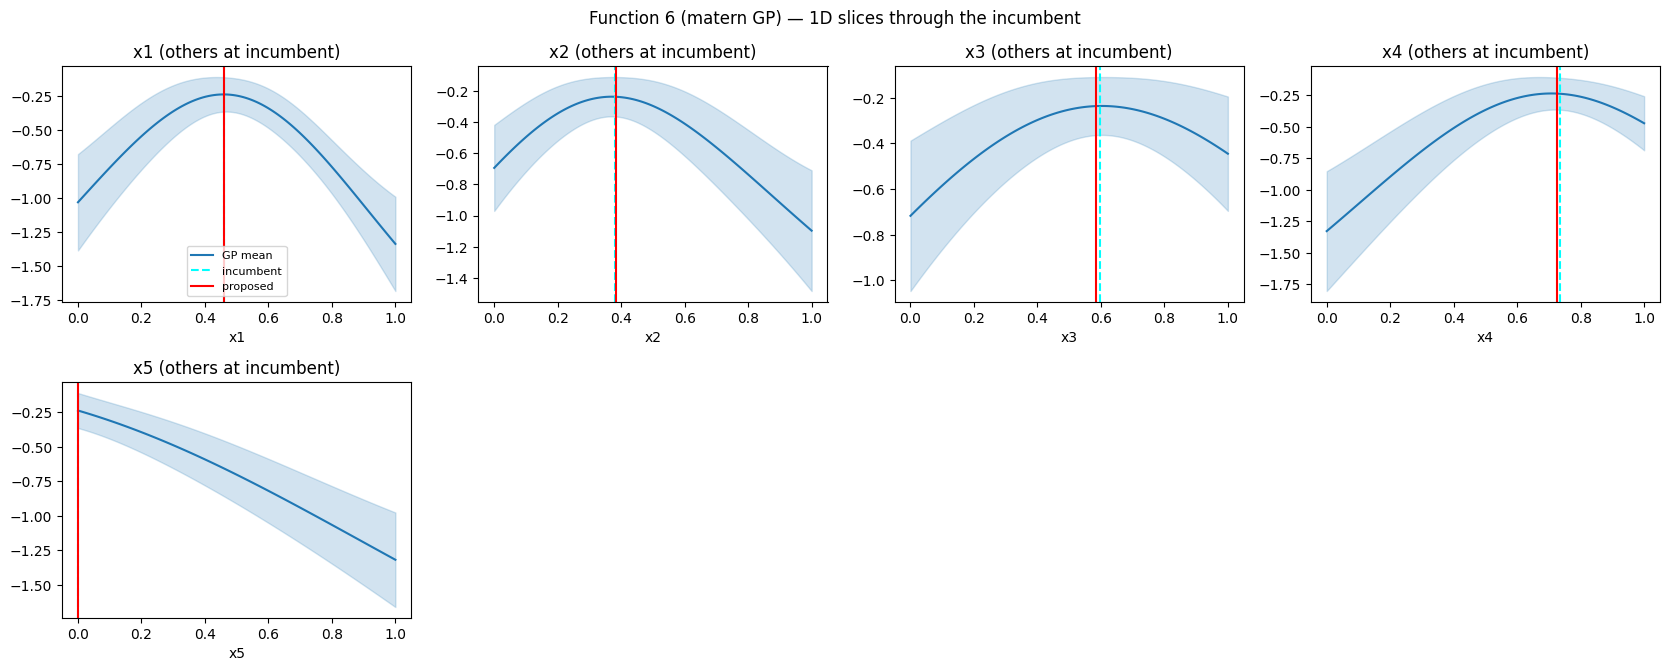

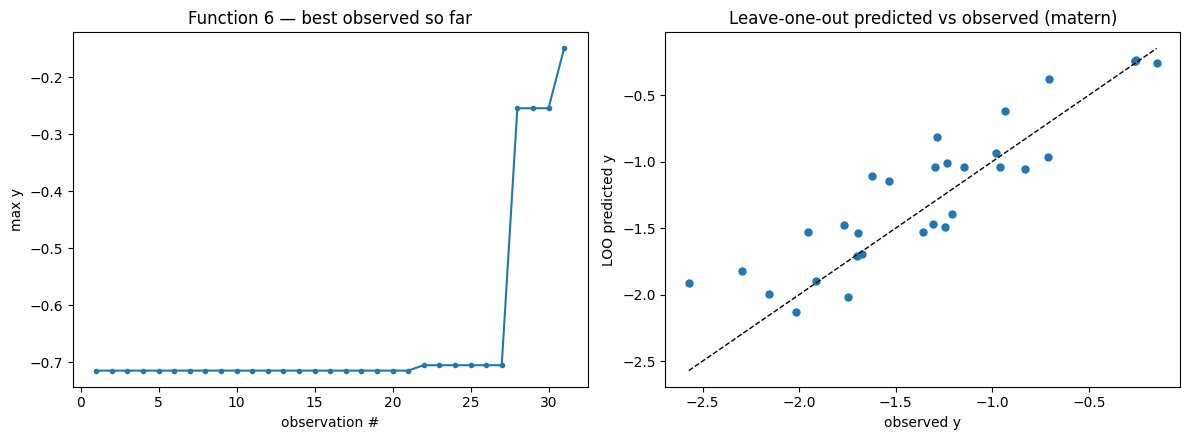

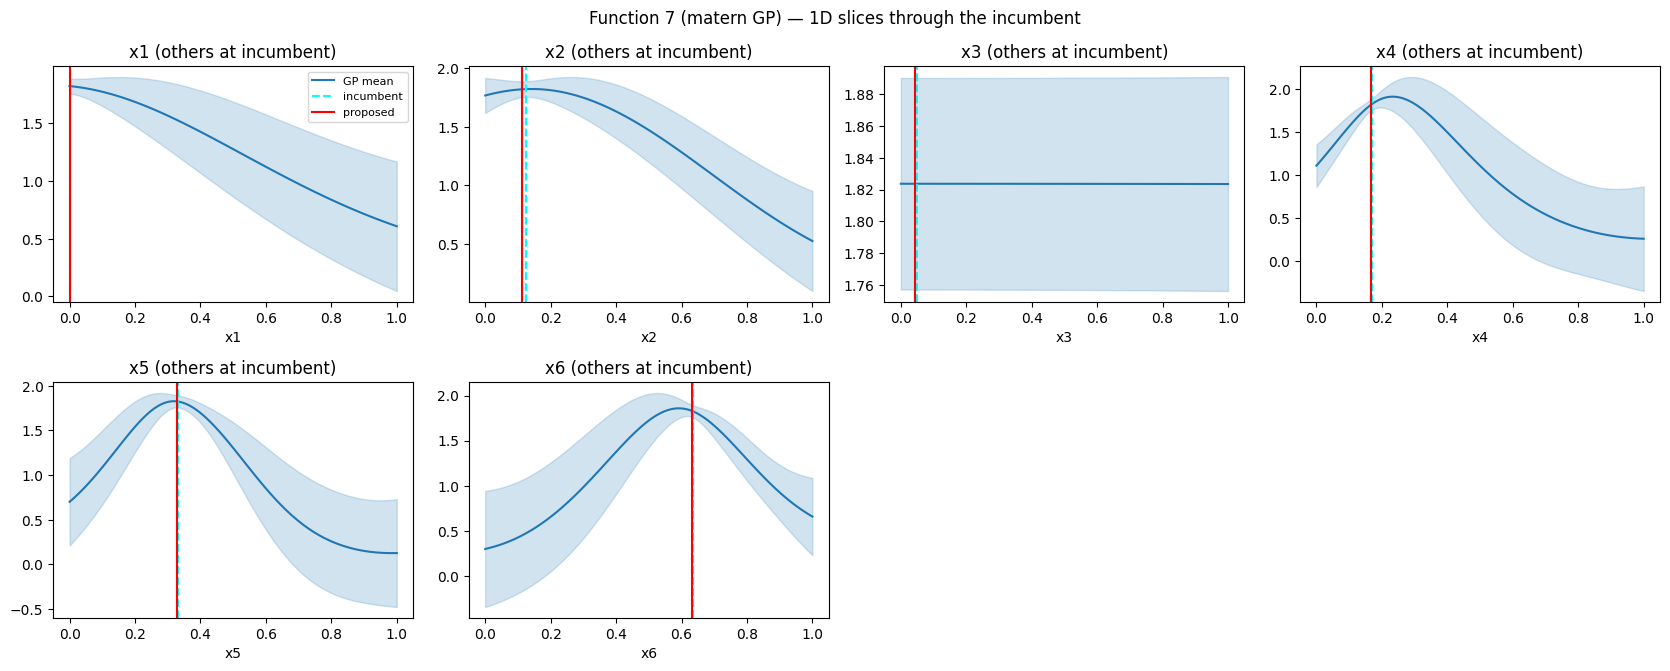

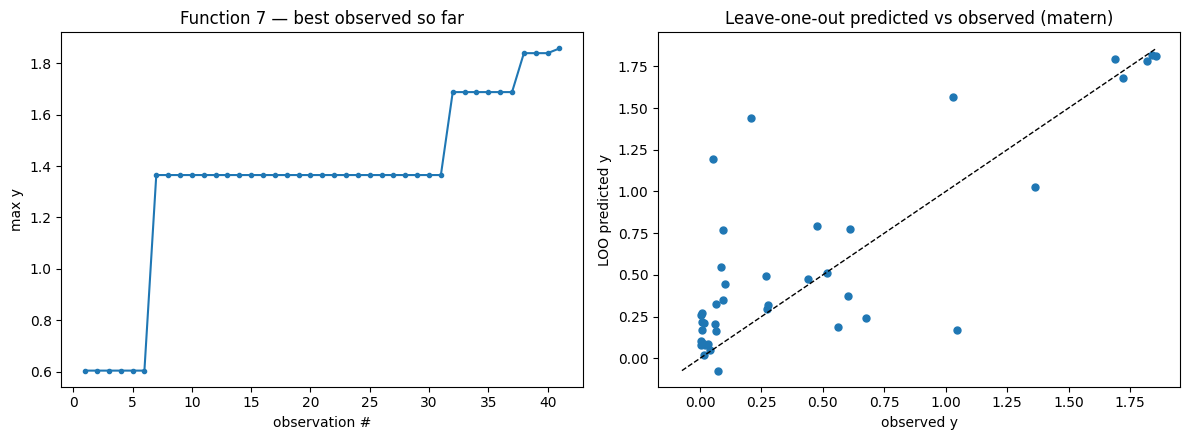

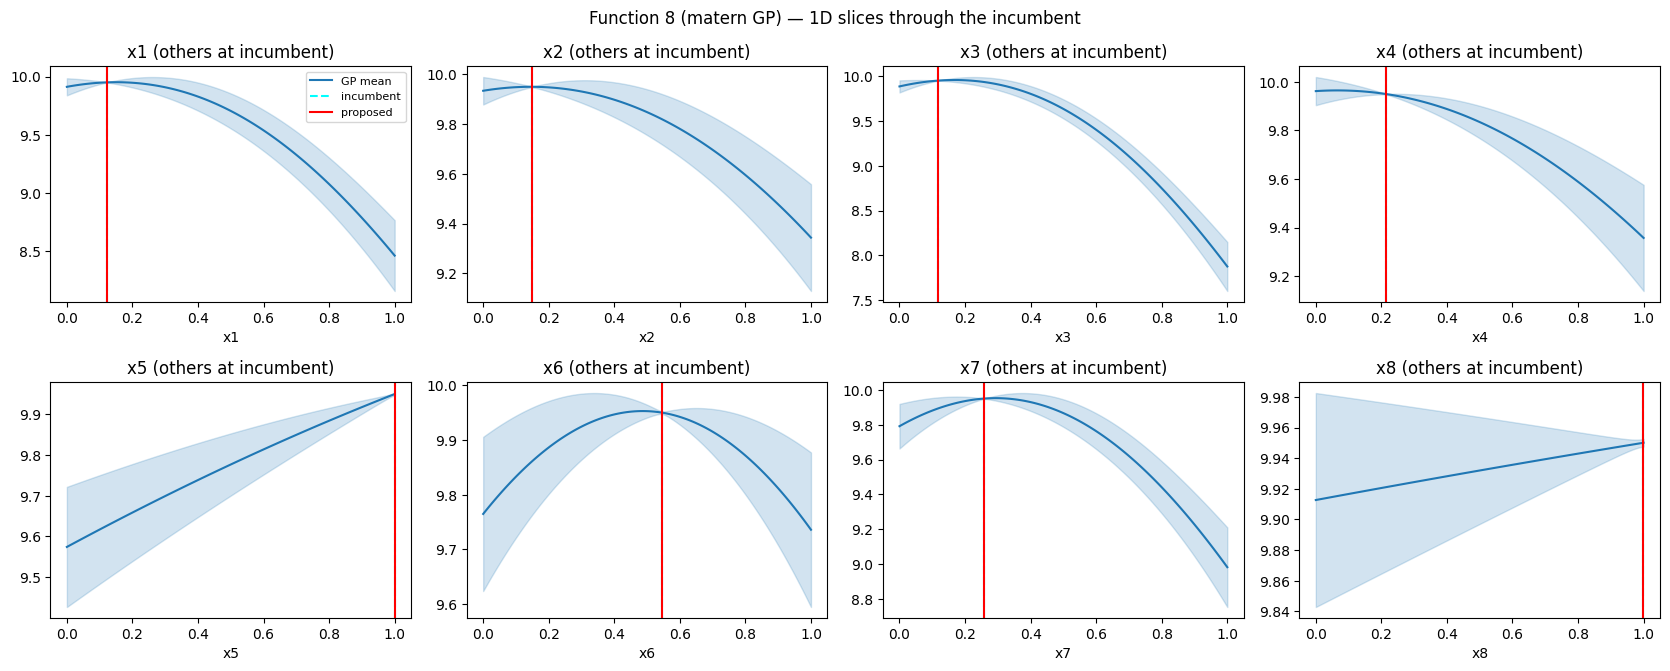

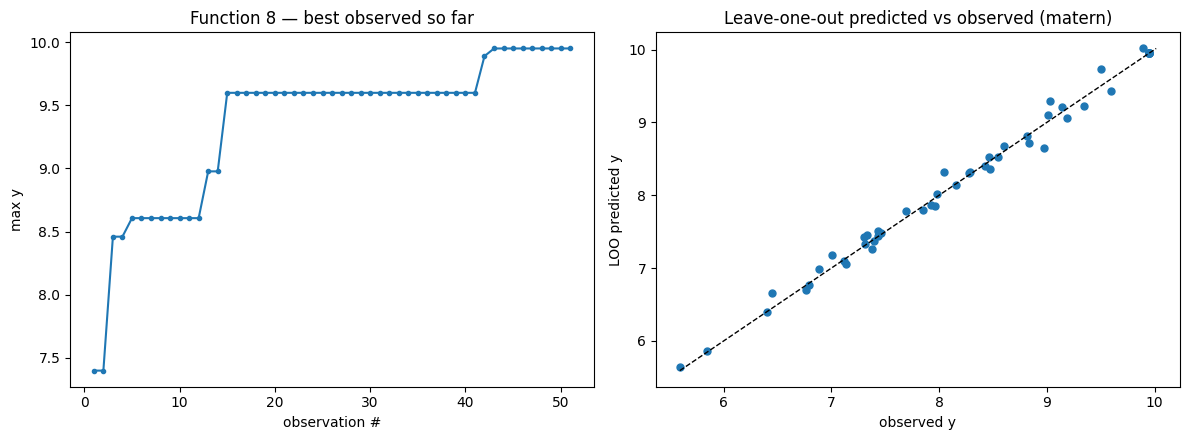

In [5]:
for fid in bo.FUNC_IDS:
    r = results[fid]; m = r["model"]
    if m.d == 2:
        bo.plot_2d(m, proposed=r["x"], save=f"{OUTDIR}/f{fid}_2d.png")
    else:
        bo.plot_slices(m, proposed_u=r["u"], save=f"{OUTDIR}/f{fid}_slices.png")
    bo.plot_diagnostics(m, save=f"{OUTDIR}/f{fid}_diag.png")
    plt.show()


## 4. Submission strings - copy one per function into the portal

In [6]:
for fid in bo.FUNC_IDS:
    print(f"f{fid}:  {results[fid]['submission']}")


f1:  0.430000-0.455000
f2:  0.699796-0.055507
f3:  0.393839-0.990914-0.084696
f4:  0.409370-0.417326-0.352834-0.440452
f5:  0.075268-0.993319-0.020411-0.829398
f6:  0.460228-0.382447-0.584549-0.726647-0.000083
f7:  0.000000-0.113447-0.042472-0.167468-0.328162-0.632507
f8:  0.121754-0.148784-0.117997-0.212840-0.999999-0.545184-0.258498-0.997235


## 5. Write the weekly reflection scaffold
Creates `weekly/reflections/weekNN.md` if it doesn't exist yet. It will **not** overwrite a
reflection you've already written (pass `overwrite=True` to force a fresh scaffold).

In [7]:
path = bo.render_reflection(WEEK, results)   # won't overwrite the written reflection
print("reflection ->", path)


reflection -> /Users/jp/PycharmProjects/MachineLearning/Capstone/weekly/reflections/week12.md


## 6. After the portal returns each y - record results for next round
Fill in the returned outputs below, run the cell, then bump `WEEK` and re-run the notebook
next module. `append_result` grows each function's CSV by one row.

In [8]:
# After the portal returns Week 12's scores, paste them in below and run.
# returned_y = {1: ..., 2: ..., 3: ..., 4: ..., 5: ..., 6: ..., 7: ..., 8: ...}
# for fid, y in returned_y.items():
#     bo.append_result(fid, results[fid]["x"], y)
# print("saved; dataset sizes now:", {fid: len(bo.load(fid)[1]) for fid in bo.FUNC_IDS})
